# SLAM (Simultaneous Localization and Mapping)

**Introduction**

SLAM is a technique used in robotics that uses a combined approach of sensor data, motion information, and probabilistic algorithms to determine a robot's position and orientation and map a its environment at the same time.

**Loading Libraries**

In [ ]:
%pip install -q U gtbook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.1/27.1 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.4 MB/s eta 0:00:00


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

import plotly.graph_objects as go
try:
  import google.colab
except:
  import plotly.io as pio
  pio.renderers.default = "png"

import gtsam
import gtsam.utils.plot as gtsam_plot

from gtbook.display import show

**GTSAM** (Georgia Tech Smoothing and Mapping) is an open-source C++ library that provides a factor graph-based approach to solving simultaneous localization and mapping (**SLAM**) and other related problems in robotics and computer vision. It's particularly well-suited for problems that can be formulated as a nonlinear least-squares optimization problem. In essence, it helps robots build maps of their environment while simultaneously tracking their own position within that map, even with noisy sensor data.

In [ ]:
#| caption: Code to re-create the factor graph from Figure [1](#fig:PoseSLAMFG).
#| label: fig:createPoseSLAMFG
graph = gtsam.NonlinearFactorGraph()
prior_model = gtsam.noiseModel.Diagonal.Sigmas((0.3, 0.3, 0.1))
graph.add(gtsam.PriorFactorPose2(1, gtsam.Pose2(0, 0, 0), prior_model))

# Create odometry (Between) factors between consecutive poses
odometry_model = gtsam.noiseModel.Diagonal.Sigmas((0.2, 0.2, 0.1))
Between = gtsam.BetweenFactorPose2
graph.add(Between(1, 2, gtsam.Pose2(2, 0, 0), odometry_model))
graph.add(Between(2, 3, gtsam.Pose2(2, 0, np.pi/2), odometry_model))
graph.add(Between(3, 4, gtsam.Pose2(2, 0, np.pi/2), odometry_model))
graph.add(Between(4, 5, gtsam.Pose2(2, 0, np.pi/2), odometry_model))

# Add the loop closure constraint
graph.add(Between(5, 2, gtsam.Pose2(2, 0, np.pi/2), odometry_model))

In [ ]:
#| caption: Create the initial estimate.
#| label: fig:create-initial-estimate
initial_estimate = gtsam.Values()
initial_estimate.insert(1, gtsam.Pose2(0.5, 0.0, 0.2))
initial_estimate.insert(2, gtsam.Pose2(2.3, 0.1, -0.2))
initial_estimate.insert(3, gtsam.Pose2(4.1, 0.1, np.pi/2))
initial_estimate.insert(4, gtsam.Pose2(4.0, 2.0, np.pi))
initial_estimate.insert(5, gtsam.Pose2(2.1, 2.1, -np.pi/2))
print(initial_estimate)

Values with 5 values:
Value 1: (gtsam::Pose2)
(0.5, 0, 0.2)

Value 2: (gtsam::Pose2)
(2.3, 0.1, -0.2)

Value 3: (gtsam::Pose2)
(4.1, 0.1, 1.5708)

Value 4: (gtsam::Pose2)
(4, 2, 3.14159)

Value 5: (gtsam::Pose2)
(2.1, 2.1, -1.5708)




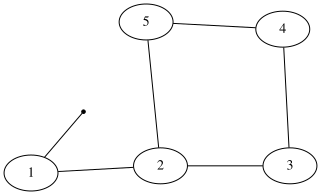

In [ ]:
#| caption: Factor graph with odometry and loop closure constraints.
#| label: fig:factor_graph_with_loop_closure
show(graph, initial_estimate, binary_edges=True)

**Gauss–Newton Nonlinear Optimizer**

The Gauss–Newton optimizer is a numerical method used to solve nonlinear least-squares problems, which makes it useful for SLAM because SLAM tries to minimize the total error in a factor graph. It works by linearizing the nonlinear error functions around the current estimate and then iteratively updating the solution to reduce the residual error.

**Pros**

Efficient for problems where the errors are mostly quadratic (common in SLAM).

Converges quickly when the initial guess is close to the correct solution.

Works well with factor graph formulations like those used in GTSAM.

**Cons**

Can fail or diverge if the initial estimate is very poor.

Doesn’t handle badly nonlinear functions as well as other optimizers like Levenberg–Marquardt.

Relies on good linearization, so noisy or inconsistent data can slow convergence.

In [ ]:
#| caption: Optimize the initial values using a Gauss-Newton nonlinear optimizer.
#| label: fig:optimize-graph
optimizer = gtsam.GaussNewtonOptimizer(graph, initial_estimate)
result = optimizer.optimize()
print("Final Result:\n{}".format(result)) #accidentally deleted something here ugh

Final Result:
Values with 5 values:
Value 1: (gtsam::Pose2)
(-1.27455e-20, 8.10528e-20, 3.0719e-20)

Value 2: (gtsam::Pose2)
(2, 1.78514e-19, 4.34263e-20)

Value 3: (gtsam::Pose2)
(4, -3.42173e-11, 1.5708)

Value 4: (gtsam::Pose2)
(4, 2, 3.14159)

Value 5: (gtsam::Pose2)
(2, 2, -1.5708)




`gtsam.Marginals` is a tool in GTSAM that calculates the marginal covariances for variables in a factor graph after optimization. A “marginal” describes how uncertain a single pose, landmark, or variable is when all other variables are considered.

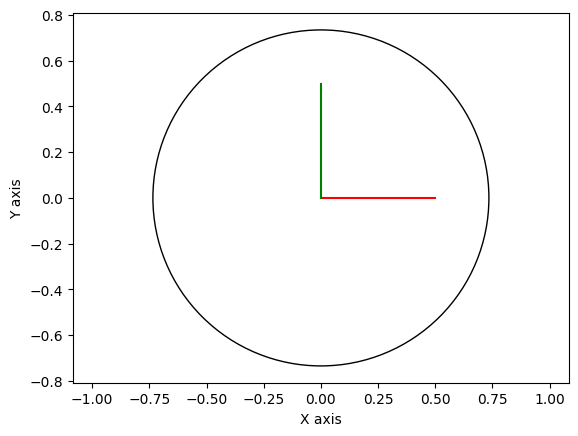

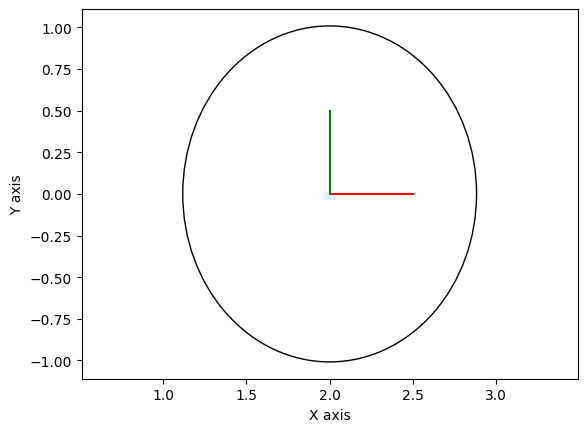

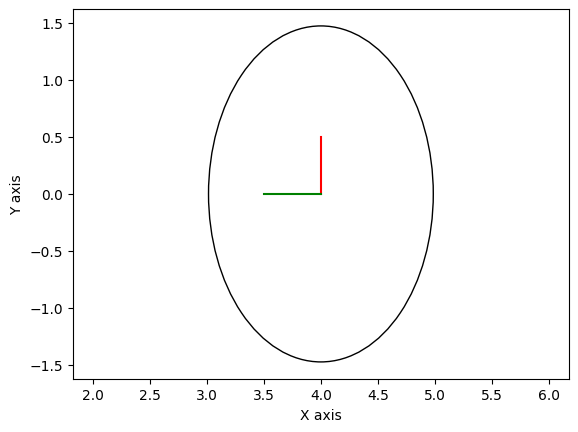

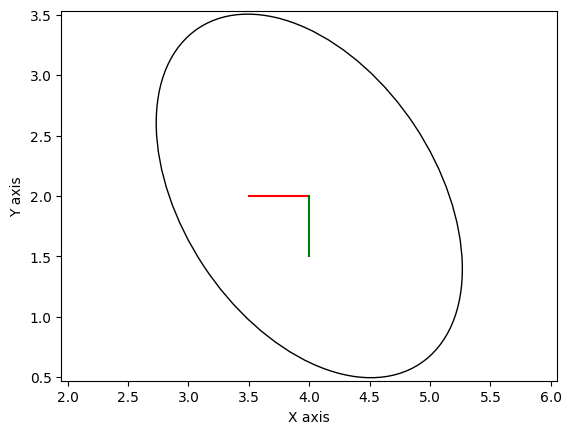

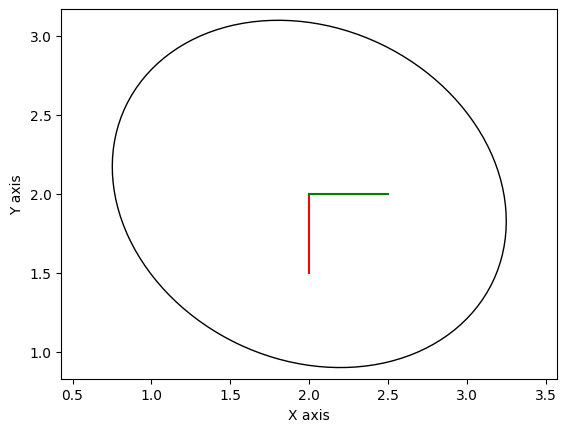

In [ ]:
#| caption: The optimized trajectory with the estimated covariances.
#| label: fig:optimized_trajectory_with_covariances
marginals = gtsam.Marginals(graph, result)
for i in range(1, 6):
  gtsam_plot.plot_pose2(0, result.atPose2(i), 0.5,
                        marginals.marginalCovariance(i))
  plt.axis('equal'); plt.show()

In [ ]:
slam_graph = gtsam.NonlinearFactorGraph()
slam_graph.add( gtsam.PriorFactorPose2(1, gtsam.Pose2(0.0, 0.0, 0.0), prior_model))
slam_graph.add(Between(1, 2, gtsam.Pose2(2.0, 0.0, 0.0), odometry_model))
slam_graph.add(Between(2, 3, gtsam.Pose2(2.0, 0.0, 0.0), odometry_model))

In [ ]:
# Add Range-Bearing measurements to two different landmarks L1 and L2
measurement_model = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.1, 0.2]))
BR = gtsam.BearingRangeFactor2D
l = {k:gtsam.symbol('l',k) for k in [1,2]} # name landmark variables
slam_graph.add(BR(1, l[1], gtsam.Rot2.fromDegrees(45),np.sqrt(4.0 + 4.0), measurement_model)) # pose 1 -*- landmark 1
slam_graph.add(BR(2, l[1], gtsam.Rot2.fromDegrees(90), 2.0,measurement_model)) # pose 2 -*- landmark 1
slam_graph.add(BR(3, l[2], gtsam.Rot2.fromDegrees(90), 2.0,measurement_model)) # pose 3 -*- landmark 2

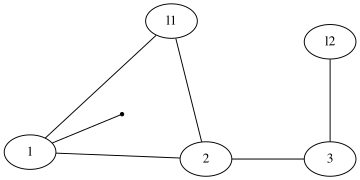

In [ ]:
#| caption: Factor graph with odometry and range-bearing constraints.
#| label: fig:factor_graph_with_range_bearing
slam_initial = gtsam.Values()
slam_initial.insert(1, gtsam.Pose2(-0.25, 0.20, 0.15))
slam_initial.insert(2, gtsam.Pose2(2.30, 0.10, -0.20))
slam_initial.insert(3, gtsam.Pose2(4.10, 0.10, 0.10))
slam_initial.insert(l[1], gtsam.Point2(1.80, 2.10))
slam_initial.insert(l[2], gtsam.Point2(4.10, 1.80))
show(slam_graph, slam_initial, binary_edges=True)

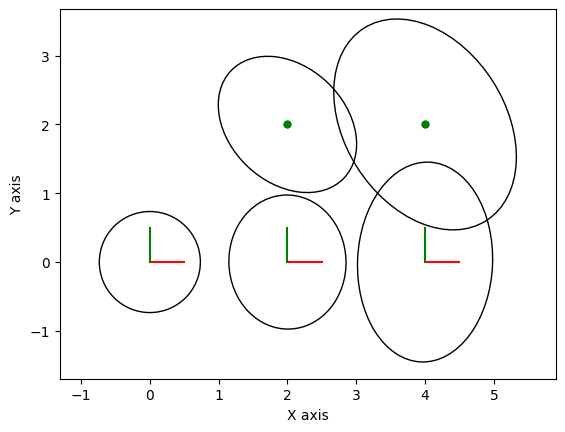

In [ ]:
#| caption: The optimized trajectory with the estimated covariances, with bearing-range measurements to landmarks.
#| label: fig:optimized_trajectory_with_covariances_and_landmarks_br
optimizer = gtsam.LevenbergMarquardtOptimizer(slam_graph, slam_initial)
slam_result = optimizer.optimize()
marginals = gtsam.Marginals(slam_graph, slam_result)
for k in [1,2,3]:
  gtsam_plot.plot_pose2(0, slam_result.atPose2(k), 0.5, marginals.marginalCovariance(k))
for j in [1,2]:
  gtsam_plot.plot_point2(0, slam_result.atPoint2(l[j]), 'g', P=marginals.marginalCovariance(l[j]))
plt.axis('equal'); plt.show()

# A Large SLAM Example

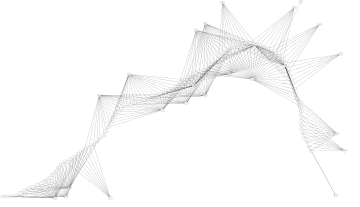

In [ ]:
#| caption: Factor graph for a more realistic example, derived from a real-world dataset.
#| label: fig:factor_graph_real_world
datafile = gtsam.findExampleDataFile('example.graph')
model = gtsam.noiseModel.Diagonal.Sigmas([0.05,0.05,2*math.pi/180])
[graph,initial] = gtsam.load2D(datafile, model)
show(graph,initial, binary_edges=True)

In [ ]:
initial_poses = gtsam.utilities.extractPose2(initial)
for i in range(initial_poses.shape[0]):
  initial.update(i, initial.atPose2(i).retract(np.random.normal(scale=0.5,size=(3,))))
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial)
result = optimizer.optimize()

In [ ]:
#| caption: Initial and optimized trajectories for a more realistic example.
#| label: fig:initial_and_optimized_trajectories
initial_poses = gtsam.utilities.extractPose2(initial)
fig = go.Figure()
fig.add_scatter(x=initial_poses[:,0], y=initial_poses[:,1], name="initial", marker=dict(color='orange'))
final_poses = gtsam.utilities.extractPose2(result)
fig.add_scatter(x=final_poses[:,0], y=final_poses[:,1], name="optimized", marker=dict(color='green'))
fig.update_yaxes(scaleanchor = "x",scaleratio = 1);
fig.show();

/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




**Conclusion**

1. SLAM which stands for Simultaneous Localization and Mapping, solves the problem of where a robot is within its environment.
2. SLAM can be complicated as each element is dependent on the other, localization depends on having a map, and mapping depends on where a robot is.
3. Factor graphs use nodes for robot poses and factors for constraints like motion or sensor observations.
4. GTSAM is a helpful solution to the dependency issue in SLAM as it uses factor graphs and probabilistic models.
5. Motion factors represent how a robot moves, which include uncertainty from odometry noise.
6. Landmarks help correct drift by orienting a robot to familiar reference points in its environment.
7. The Gauss-Newton optimizer is used to refine pose estimates iteratively by minimizing overall error in the factor graph.
8. One drawback of Gauss-Newton is that it may converge slowly or get stuck.
9. GTSAM allows you to query marginal covariances, which show how uncertain each variable is after optimization.
10. By visualizing these uncertainties, it helps to demonstrate why some parts of the map are more reliable than others.
11. Running the larger SLAM example showed how adding more measurements and constraints leads to a more accurate and stable map.
12. Loop Closures correct accumulated drift when robots revisit a known location.
13. Sensor data is extremely important in SLAM and noisy data can lead to poor mapping and localization.
14. SLAM is a highly modular system where motion models, landmarks, and otimizers are all used to define a factor graph structure.
15. Modern mobile robots rely on SLAM to navigate dynamic and complex environments using real time calculations and data.

In [ ]:
# To convert ipynb to html:
# Download jupyter notebook. Upload to colab files. Copy file path.
%%shell
jupyter nbconvert --to html '/content/Stanton_Lab_10_SLAM.ipynb'

[NbConvertApp] Converting notebook /content/Stanton_Lab_10_SLAM.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 9 image(s).
[NbConvertApp] Writing 751198 bytes to /content/Stanton_Lab_10_SLAM.html
